### 09 - Conclusions

Summary of all models, answers to the research questions, and limitations.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})
os.makedirs('../outputs/figures/09_conclusions', exist_ok=True)

mc = pd.read_csv('../outputs/model_comparison.csv')
mc

,model,rmse,mae,r2_train,auc
0,LM,7623.700,6125.800,0.7855,NaN
1,GLM_Poisson,2.575,1.441,0.6887,NaN
2,GLM_Binomial,NaN,NaN,0.5254,0.9593
3,GAM,7199.800,5829.100,0.8081,NaN
4,SVM,4768.800,3481.300,NaN,NaN
5,"NN (128,64,32)",5384.100,3791.800,NaN,NaN


## 1. Model Comparison

In [2]:
# regression models (demand in kW)
reg = mc[mc['model'].isin(['LM', 'GAM', 'SVM', 'NN (128,64,32)'])][['model', 'rmse', 'mae', 'r2_train']].copy()
reg.columns = ['Model', 'RMSE (kW)', 'MAE (kW)', 'R2 train']
reg = reg.reset_index(drop=True)
print('Regression models')
display(reg)

# classification / count models
clf = mc[mc['model'].isin(['GLM_Poisson', 'GLM_Binomial'])][['model', 'rmse', 'mae', 'r2_train', 'auc']].copy()
clf.columns = ['Model', 'RMSE', 'MAE', 'R2 train', 'AUC']
clf = clf.reset_index(drop=True)
print('\nClassification / count models')
display(clf)

Regression models


,Model,RMSE (kW),MAE (kW),R2 train
0,LM,7623.7,6125.8,0.7855
1,GAM,7199.8,5829.1,0.8081
2,SVM,4768.8,3481.3,NaN
3,"NN (128,64,32)",5384.1,3791.8,NaN



Classification / count models


,Model,RMSE,MAE,R2 train,AUC
0,GLM_Poisson,2.575,1.441,0.6887,NaN
1,GLM_Binomial,NaN,NaN,0.5254,0.9593


## 2. RMSE Comparison (Regression Models)

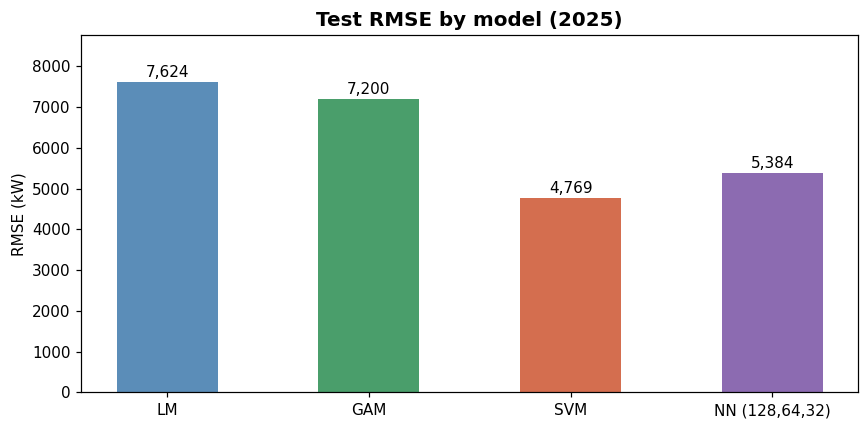

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = ['#5b8db8', '#4a9e6b', '#d46e4f', '#8c6bb1']
ax.bar(reg['Model'], reg['RMSE (kW)'], color=colors, width=0.5)

for i, v in enumerate(reg['RMSE (kW)']):
    ax.text(i, v + 50, f'{v:,.0f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('RMSE (kW)')
ax.set_title('Test RMSE by model (2025)', fontweight='bold')
ax.set_ylim(0, reg['RMSE (kW)'].max() * 1.15)
plt.tight_layout()
plt.savefig('../outputs/figures/09_conclusions/09_20_rmse_comparison.png', bbox_inches='tight')
plt.show()

## 3. Research Questions

**RQ1 - What drives electricity demand?**

Temperature and hour of day are the main drivers. The GAM shows that the T effect is non-linear:
demand rises sharply below ~5C and stays roughly flat above ~20C. Hour of day has a strong
cyclic pattern (peak around 8-9h and 19-20h). The SVM achieves the lowest RMSE (4,769 kW,
6.4% of mean) of all four regression models, followed by the NN (5,384 kW).

**RQ2 - Can we predict peak hours?**

Yes. The GLM Binomial predicts is_peak with AUC 0.96 and 94% accuracy. Peaks cluster in winter
mornings on weekdays. Solar radiation (StrGlo) reduces peak probability, likely because solar
generation offsets grid demand during daylight hours.

**RQ3 - Can we model daily peak counts?**

The GLM Poisson captures the seasonal pattern in peak_hours_per_day reasonably well (R2 0.69).
The main limitation is overdispersion (ratio 1.82): the data has more variance than the Poisson
distribution assumes, so the standard errors are underestimated.

## 4. Limitations

- Overdispersion in the Poisson model. A negative binomial GLM would handle this better.
- No lag features (e.g. demand at t-1, t-24). Autoregressive structure is ignored.
- Meteo data only from 2022: we cannot tell if 2022-2025 is representative of a longer trend.
- The comparison is not fully fair: SVM had a grid search while LM and GAM used defaults or GCV.
  With the same tuning effort the gap between models might look different.

## 5. Use of Generative AI

We used a generative AI assistant to help with code structure, debugging, and concept explanations.
Specifically: generating the notebook templates, fixing the sklearn 1.8 `best_loss_` issue,
and explaining why TimeSeriesSplit is needed instead of random KFold.
All outputs were verified manually, hyperparameters were adjusted by us, and the text of this
report was written and edited by us.